# Causal Analysis for VLST Dataset

This notebook estimates causal effects for binary exposures on **Stent thrombosis** using multiple methods:

- Propensity score weighting (ATE and ATT)
- Propensity score matching (ATT)
- Doubly robust AIPW (ATE)
- Balance diagnostics (SMD)
- Sensitivity checks (weight trimming)

Default exposure in this template is `Current drinking`.
You can change `TREATMENT_COL` in the configuration cell.

## 1) Environment Setup (PEP 668-safe)

Run this once to ensure required packages are available. If system Python is externally managed, this installs into a local `venv` and registers a Jupyter kernel.

In [1]:
import os
import sys
import subprocess
import importlib

required = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
}


def module_available(name):
    try:
        importlib.import_module(name)
        return True
    except ImportError:
        return False


missing = [pip_name for mod, pip_name in required.items() if not module_available(mod)]
print("Active Python:", sys.executable)

if missing:
    venv_dir = os.path.join(os.getcwd(), "venv")
    venv_py = os.path.join(venv_dir, "bin", "python")
    if not os.path.exists(venv_dir):
        subprocess.check_call([sys.executable, "-m", "venv", venv_dir])
    subprocess.check_call([venv_py, "-m", "pip", "install", "--upgrade", "pip"])
    subprocess.check_call([venv_py, "-m", "pip", "install", *missing, "ipykernel"])
    subprocess.check_call(
        [
            venv_py,
            "-m",
            "ipykernel",
            "install",
            "--user",
            "--name",
            "vlst-causal-venv",
            "--display-name",
            "Python (vlst-causal-venv)",
        ]
    )
    print("\nInstalled into local venv. Switch kernel to: Python (vlst-causal-venv)")
else:
    print("All required packages already available.")

Active Python: /usr/bin/python
  Using cached pip-26.0.1-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-26.0.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 25.3
    Uninstalling pip-25.3:
      Successfully uninstalled pip-25.3
  Using cached matplotlib-3.10.8-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scipy-1.17.1-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached scikit_learn-1.8.0-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached ipykernel-7.2.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using c

  Using cached stack_data-0.6.3-py3-none-any.whl.metadata (18 kB)
  Using cached wcwidth-0.6.0-py3-none-any.whl.metadata (30 kB)
  Using cached parso-0.8.6-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached platformdirs-4.9.4-py3-none-any.whl.metadata (4.7 kB)
  Using cached ptyprocess-0.7.0-py2.py3-none-any.whl.metadata (1.3 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
  Using cached executing-2.2.1-py2.py3-none-any.whl.metadata (8.9 kB)
  Using cached asttokens-3.0.1-py3-none-any.whl.metadata (4.9 kB)
  Using cached pure_eval-0.2.3-py3-none-any.whl.metadata (6.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 3.3 MB/s  0:00:03a 0:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 1.4 MB/s  0:00:11 eta 0:00:010:01:01
Using cached matplotlib-3.10.8-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (9.8 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached scipy-1.17.1-cp314-cp314-manylinux_2_27_

## 2) Imports and Data Loading

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from scipy import stats

pd.set_option("display.max_columns", 200)

RAW_PATH = "/home/fadia/Documents/vlst/data/raw/VLST.csv"
OUT_DIR = "/home/fadia/Documents/vlst/data/result/causal"
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(RAW_PATH)
print("Data shape:", df.shape)
print("Output dir:", OUT_DIR)

df.head(3)

Data shape: (5185, 85)
Output dir: /home/fadia/Documents/vlst/data/result/causal


,NO.,Stent thrombosis,Name,Age,Men,Time since stent implantation,Diabetes,Hypertension,HL,Current smoker,Current drinking,Stroke/TIA,History of peripheral vascualr disease,Chronic renal insufficiency,History of HF,Previous CABG,Previous PCI,Previous MI,Initial diagnosis-AMI,STEMI,NSTEMI,UA,Cardiogenic shock,NO.of vessels,Multi-vessel CAD,Single-vessel disease,2-vessel disease,3-vessel disease,Chronic total occlusion,Moderate/severe calcification,Moderate/severe tortuosity,Lesion location-Ostial,Proximal,Bifurcation,Visual thrombus,Aneurysm,Vessel dialation,Ulceration,P-LM,P-LAD,P-LCX,P-RCA,Pre-TIMI flow-3,TIMI-2,TIMI-1,TIMI-0,Staged PCI,Thrombus aspiration,Slow flow,No reflow,Dissection,Stent type-SES,PES,ZES,EVS,Min-stent diameter,Max-stent diameter,Total stent length,Stent release pressure,No.of stents per lesion,stent overlap,1.1:1Post dilation,No postdilation,LV,LVEF,CaI,WBC,HGB,Platelet,Cre,eGFR,CKD60,CKD90,CKD5,TCL,LDL,HDL,TG,Fast-Glu,HbA1c,Fiberinogen,Aspirin,Clopidogrel,Ticagrelor,DAPT
0,1,0,NaN,36,1,1243,1,1,0,1,1,0,0,0,0,0,0,0,1,1,0,0,0,2,1,0,1,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,Partner,1,0,0,4.0,4.0,18,16,1,0,1,0,46,56,21.00,14.89,164.0,236.0,72.1,157.73,0.0,0.0,1.0,3.80,2.60,0.87,4.20,7.64,6.8,2.14,1,0,0,0
1,2,0,NaN,47,1,1540,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,2,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,Partner,1,0,0,3.0,3.0,15,14,1,0,0,1,46,54,0.01,10.12,143.0,234.0,77.0,145.68,0.0,0.0,1.0,3.68,1.41,1.88,1.37,4.99,4.6,1.71,1,1,0,1
2,3,0,NaN,45,1,1567,1,0,1,1,0,0,0,0,0,0,0,0,1,0,1,0,0,3,1,0,0,1,0,1,1,1,0,1,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,Resolute,0,1,0,3.0,3.0,18,16,1,0,1,0,46,53,199.00,6.54,154.0,200.0,63.0,185.68,0.0,0.0,1.0,4.52,2.71,1.03,2.38,8.10,9.3,3.01,1,1,0,1


## 3) Causal Question and DAG Assumptions

Define exposure, outcome, and adjustment covariates.

Assumptions (state explicitly in report):
- Exchangeability (no unmeasured confounding after adjustment)
- Positivity (both treatment levels possible for all covariate profiles)
- Consistency
- Correct model specification (for PS/outcome models)

In [2]:
# --- Configuration ---
TREATMENT_COL = "Current drinking"   # change exposure here
TARGET_CANDIDATES = ["Stent thrombosis", "stent thrombosis", "Stent Thrombosis"]

TARGET_COL = next((c for c in TARGET_CANDIDATES if c in df.columns), None)
if TARGET_COL is None:
    raise ValueError(f"Target column not found. Tried: {TARGET_CANDIDATES}")

if TREATMENT_COL not in df.columns:
    raise ValueError(f"Treatment column '{TREATMENT_COL}' not found in dataset.")

# Exclude IDs/non-causal labels
exclude_cols = {TARGET_COL, TREATMENT_COL, "NO.", "No.", "Name"}

# Candidate adjustment set (numeric + binary-like columns by default)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
candidate_covariates = [c for c in numeric_cols if c not in exclude_cols]

# Optional manual override (recommended after DAG review)
USER_ADJUSTMENT_COLS = []
ADJUSTMENT_COLS = USER_ADJUSTMENT_COLS if len(USER_ADJUSTMENT_COLS) > 0 else candidate_covariates

print("Treatment:", TREATMENT_COL)
print("Outcome:", TARGET_COL)
print("Adjustment covariates:", len(ADJUSTMENT_COLS))
print(ADJUSTMENT_COLS[:20])

# Keep analysis-ready rows
causal_df = df[[TREATMENT_COL, TARGET_COL] + ADJUSTMENT_COLS].copy()
causal_df = causal_df.dropna()
causal_df = causal_df[causal_df[TREATMENT_COL].isin([0, 1]) & causal_df[TARGET_COL].isin([0, 1])]

print("Analysis-ready shape:", causal_df.shape)
print(causal_df[[TREATMENT_COL, TARGET_COL]].value_counts().rename("n"))

Treatment: Current drinking
Outcome: Stent thrombosis
Adjustment covariates: 80
['Age', 'Men', 'Time since stent implantation', 'Diabetes', 'Hypertension', 'HL', 'Current smoker', 'Stroke/TIA', 'History of peripheral vascualr disease', 'Chronic renal insufficiency', 'History of HF', 'Previous CABG', 'Previous PCI', 'Previous MI', 'Initial diagnosis-AMI', 'STEMI', 'NSTEMI', 'UA', 'Cardiogenic shock', 'NO.of vessels']
Analysis-ready shape: (5185, 82)
Current drinking  Stent thrombosis
0                 0                   4342
1                 0                    751
0                 1                     79
1                 1                     13
Name: n, dtype: int64


## 4) Baseline Imbalance Diagnostics (Before Adjustment)

Use standardized mean difference (SMD) for each covariate between treatment groups.

Top imbalance covariates (pre-adjustment):


,Covariate,SMD,Abs_SMD
6,Current smoker,0.647951,0.647951
1,Men,0.598019,0.598019
62,HGB,0.364138,0.364138
65,eGFR,0.360428,0.360428
67,CKD90,-0.311041,0.311041
68,CKD5,-0.258009,0.258009
0,Age,-0.228022,0.228022
63,Platelet,-0.152524,0.152524
64,Cre,0.138214,0.138214
8,History of peripheral vascualr disease,-0.093779,0.093779


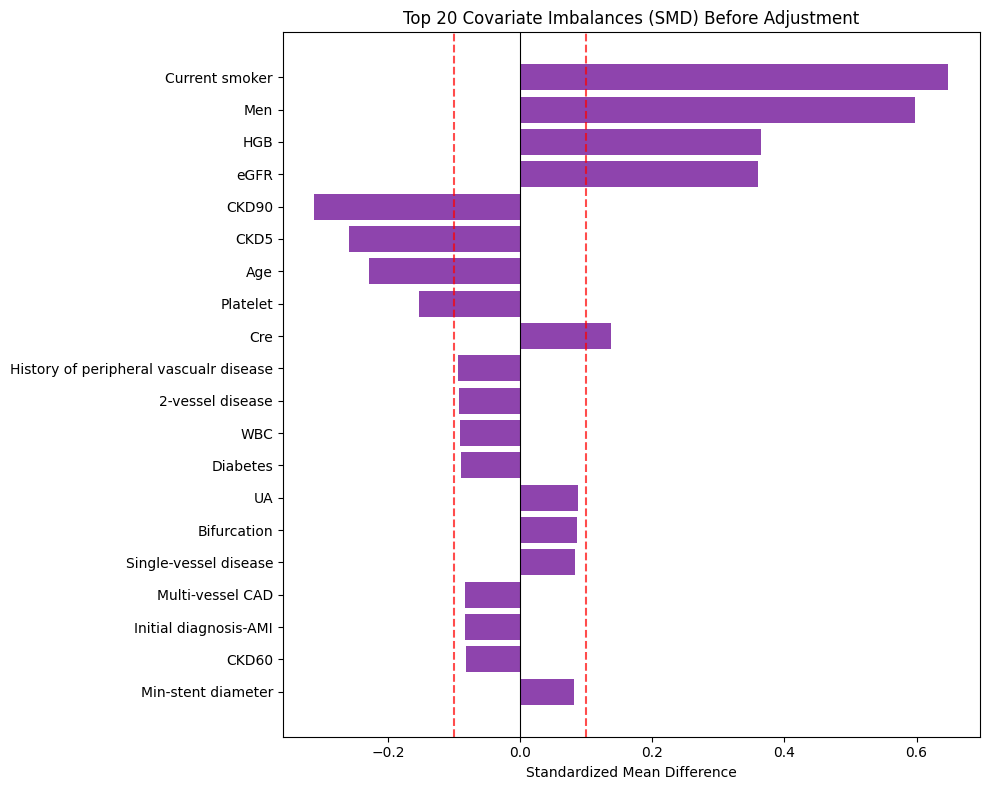

In [3]:
def smd(x_t, x_c):
    m1, m0 = np.mean(x_t), np.mean(x_c)
    v1, v0 = np.var(x_t, ddof=1), np.var(x_c, ddof=1)
    pooled = np.sqrt((v1 + v0) / 2)
    return 0.0 if pooled == 0 else (m1 - m0) / pooled


treated = causal_df[causal_df[TREATMENT_COL] == 1]
control = causal_df[causal_df[TREATMENT_COL] == 0]

smd_rows = []
for c in ADJUSTMENT_COLS:
    try:
        s = smd(treated[c].values, control[c].values)
        smd_rows.append({"Covariate": c, "SMD": s, "Abs_SMD": abs(s)})
    except Exception:
        pass

smd_df = pd.DataFrame(smd_rows).sort_values("Abs_SMD", ascending=False)
print("Top imbalance covariates (pre-adjustment):")
display(smd_df.head(20))

plt.figure(figsize=(10, 8))
plot_df = smd_df.head(20).iloc[::-1]
plt.barh(plot_df["Covariate"], plot_df["SMD"], color="#8e44ad")
plt.axvline(0, color="black", linewidth=0.8)
plt.axvline(0.1, color="red", linestyle="--", alpha=0.7)
plt.axvline(-0.1, color="red", linestyle="--", alpha=0.7)
plt.title("Top 20 Covariate Imbalances (SMD) Before Adjustment")
plt.xlabel("Standardized Mean Difference")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "smd_before_adjustment.png"), dpi=300)
plt.show()

## 5) Propensity Score Model and IPTW Estimates

IPTW results
ATE risk difference (treated - control): 0.002132
ATT risk difference (treated - matched control weighting): 0.003098

Propensity summary:
count    5185.000000
mean        0.435922
std         0.218296
min         0.026159
25%         0.259777
50%         0.423407
75%         0.636460
max         0.917950
dtype: float64


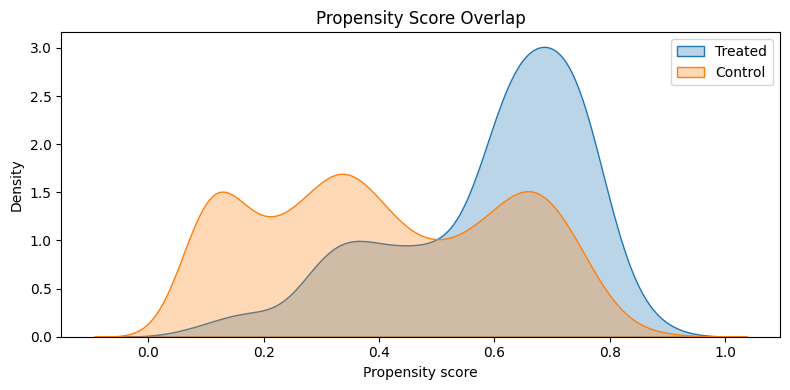

In [4]:
X = causal_df[ADJUSTMENT_COLS].values
t = causal_df[TREATMENT_COL].values.astype(int)
y = causal_df[TARGET_COL].values.astype(int)

ps_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(max_iter=2000, class_weight="balanced")),
    ]
)
ps_model.fit(X, t)
ps = ps_model.predict_proba(X)[:, 1]

# Stabilize / clip for numerical safety
ps = np.clip(ps, 1e-3, 1 - 1e-3)
causal_df["ps"] = ps

# IPTW weights
w_ate = t / ps + (1 - t) / (1 - ps)
w_att = np.where(t == 1, 1.0, ps / (1 - ps))

causal_df["w_ate"] = w_ate
causal_df["w_att"] = w_att

# Weighted risk estimates
def weighted_mean(x, w):
    return np.sum(x * w) / np.sum(w)

risk1_ate = weighted_mean(y[t == 1], w_ate[t == 1])
risk0_ate = weighted_mean(y[t == 0], w_ate[t == 0])
ate_rd = risk1_ate - risk0_ate

risk1_att = weighted_mean(y[t == 1], w_att[t == 1])
risk0_att = weighted_mean(y[t == 0], w_att[t == 0])
att_rd = risk1_att - risk0_att

print("IPTW results")
print(f"ATE risk difference (treated - control): {ate_rd:.6f}")
print(f"ATT risk difference (treated - matched control weighting): {att_rd:.6f}")
print("\nPropensity summary:")
print(pd.Series(ps).describe())

plt.figure(figsize=(8, 4))
sns.kdeplot(ps[t == 1], label="Treated", fill=True, alpha=0.3)
sns.kdeplot(ps[t == 0], label="Control", fill=True, alpha=0.3)
plt.title("Propensity Score Overlap")
plt.xlabel("Propensity score")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "propensity_overlap.png"), dpi=300)
plt.show()

## 6) Propensity Score Matching (ATT)

Simple 1:1 nearest-neighbor matching on propensity score (with replacement).

In [5]:
treated_idx = np.where(t == 1)[0]
control_idx = np.where(t == 0)[0]

ps_t = ps[treated_idx].reshape(-1, 1)
ps_c = ps[control_idx].reshape(-1, 1)

nn = NearestNeighbors(n_neighbors=1, metric="euclidean")
nn.fit(ps_c)
dists, nn_idx = nn.kneighbors(ps_t)
matched_control_idx = control_idx[nn_idx.flatten()]

y_t = y[treated_idx]
y_c_match = y[matched_control_idx]
att_match_rd = np.mean(y_t - y_c_match)

print("PS Matching (ATT) risk difference:", round(float(att_match_rd), 6))
print("Mean absolute PS distance:", round(float(np.mean(dists)), 6))

PS Matching (ATT) risk difference: 0.005236
Mean absolute PS distance: 0.000116


## 7) Doubly Robust AIPW (ATE)

Combines propensity weighting + outcome regression. More robust if either PS model or outcome model is correctly specified.

In [6]:
# Outcome models m1(x)=P(Y=1|T=1,X), m0(x)=P(Y=1|T=0,X)
model_y1 = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(max_iter=2000, class_weight="balanced")),
    ]
)
model_y0 = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(max_iter=2000, class_weight="balanced")),
    ]
)

model_y1.fit(X[t == 1], y[t == 1])
model_y0.fit(X[t == 0], y[t == 0])

m1 = model_y1.predict_proba(X)[:, 1]
m0 = model_y0.predict_proba(X)[:, 1]

# AIPW score for ATE
phi = (t * (y - m1) / ps) - ((1 - t) * (y - m0) / (1 - ps)) + (m1 - m0)
aipw_ate = np.mean(phi)

print("AIPW ATE risk difference:", round(float(aipw_ate), 6))

AIPW ATE risk difference: 0.0158


## 8) Sensitivity Checks (Weight Trimming)

In [7]:
def iptw_ate_with_trim(trim_low=0.01, trim_high=0.99):
    keep = (ps >= trim_low) & (ps <= trim_high)
    t_k = t[keep]
    y_k = y[keep]
    ps_k = ps[keep]
    w = t_k / ps_k + (1 - t_k) / (1 - ps_k)
    r1 = np.sum(y_k[t_k == 1] * w[t_k == 1]) / np.sum(w[t_k == 1])
    r0 = np.sum(y_k[t_k == 0] * w[t_k == 0]) / np.sum(w[t_k == 0])
    return r1 - r0, keep.mean()

rows = []
for q in [0.005, 0.01, 0.02, 0.05]:
    rd, kept = iptw_ate_with_trim(q, 1 - q)
    rows.append({"trim": q, "iptw_ate_rd": rd, "fraction_kept": kept})

sens_df = pd.DataFrame(rows)
display(sens_df)
sens_df.to_csv(os.path.join(OUT_DIR, "sensitivity_weight_trimming.csv"), index=False)

,trim,iptw_ate_rd,fraction_kept
0,0.005,0.002132,1.000000
1,0.010,0.002132,1.000000
2,0.020,0.002132,1.000000
3,0.050,0.002321,0.995371


## 9) Final Results Table and Export

In [8]:
results = pd.DataFrame(
    [
        {"method": "IPTW_ATE", "risk_difference": float(ate_rd)},
        {"method": "IPTW_ATT", "risk_difference": float(att_rd)},
        {"method": "PSM_ATT", "risk_difference": float(att_match_rd)},
        {"method": "AIPW_ATE", "risk_difference": float(aipw_ate)},
    ]
)

print("Causal effect estimates (risk difference scale):")
display(results)

results.to_csv(os.path.join(OUT_DIR, "causal_effect_estimates.csv"), index=False)
smd_df.to_csv(os.path.join(OUT_DIR, "smd_before_adjustment.csv"), index=False)

print("Saved:")
print("-", os.path.join(OUT_DIR, "causal_effect_estimates.csv"))
print("-", os.path.join(OUT_DIR, "smd_before_adjustment.csv"))
print("-", os.path.join(OUT_DIR, "sensitivity_weight_trimming.csv"))
print("-", os.path.join(OUT_DIR, "propensity_overlap.png"))
print("-", os.path.join(OUT_DIR, "smd_before_adjustment.png"))

Causal effect estimates (risk difference scale):


,method,risk_difference
0,IPTW_ATE,0.002132
1,IPTW_ATT,0.003098
2,PSM_ATT,0.005236
3,AIPW_ATE,0.015800


Saved:
- /home/fadia/Documents/vlst/data/result/causal/causal_effect_estimates.csv
- /home/fadia/Documents/vlst/data/result/causal/smd_before_adjustment.csv
- /home/fadia/Documents/vlst/data/result/causal/sensitivity_weight_trimming.csv
- /home/fadia/Documents/vlst/data/result/causal/propensity_overlap.png
- /home/fadia/Documents/vlst/data/result/causal/smd_before_adjustment.png
